Explain each component in the link including model fitness, coefficients and other tests. (10)
Also perform graphical presentations and interpret your findings. (5)

Download daily stock prices data of a company, which should not be taken by any other student using Yahoo Finance. (5)

In [2]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf

In [4]:
symbol = "BATS.L"   # British American Tobacco PLC on LSE
data = yf.download(symbol, start="2014-01-01", end="2024-12-31", auto_adjust=True)
data["ROI"]= ((data["Close"]-data["Open"])/data["Open"])*100
data['Daily_Return'] = data['Close'].pct_change()
data.head(20)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,ROI,Daily_Return
Ticker,BATS.L,BATS.L,BATS.L,BATS.L,BATS.L,,
Date,,,,,,,
2014-01-02,3182.964600,3227.620377,3182.468424,3227.620377,2054699,-1.383551,NaN
2014-01-03,3175.521484,3204.299648,3172.048258,3183.460288,1345823,-0.249377,-0.002338
2014-01-06,3180.979492,3194.376224,3161.628658,3171.055987,1512558,0.312940,0.001719
2014-01-07,3161.133301,3194.873226,3161.133301,3177.507088,2108532,-0.515303,-0.006239
2014-01-08,3130.369873,3169.545916,3063.882385,3143.766606,3274350,-0.426136,-0.009732
2014-01-09,3087.697754,3142.277017,3081.247477,3128.880289,2593978,-1.316207,-0.013632
2014-01-10,3060.904785,3118.957283,3057.957534,3117.964933,3387571,-1.830045,-0.008677
2014-01-13,3019.226318,3072.317069,2994.913732,3065.370615,4887790,-1.505342,-0.013616


In [5]:
stock = yf.Ticker(symbol)
info = stock.info
print(f"Symbol: {symbol}")
print(f"Name: {info.get('shortName', 'N/A')}")
print(f"Market: {info.get('market', 'N/A')}")
print(f"Sector: {info.get('sector', 'N/A')}")

Symbol: BATS.L
Name: BRITISH AMERICAN TOBACCO PLC OR
Market: gb_market
Sector: Consumer Defensive


Perform ARIMA model using python coding using steps provided in the link below: (5)

In [6]:
!pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Import the library
from pmdarima import auto_arima

In [8]:
import warnings
warnings.filterwarnings("ignore")
# Fit the ARIMA model
model = auto_arima(data['ROI'],  start_p = 1, start_q = 1,
                   max_p = 5, max_q = 5,        # Increase search range for non-seasonal terms
                   d = 0,                        # CRITICAL: Fix non-seasonal differencing at 0
                   seasonal = False,             # CRITICAL: Turn off seasonality
                   trace = True,
                   error_action ='ignore',
                   suppress_warnings = True,
                   stepwise = True)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=9230.447, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=9229.705, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=9230.262, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=9230.354, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=9231.504, Time=0.05 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.446 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2778
Model:                        SARIMAX   Log Likelihood               -4613.853
Date:                Thu, 14 May 2026   AIC                           9229.705
Time:                        22:55:58   BIC                           9235.635
Sample:                             0   HQIC                          9231.846
                               - 2778                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.6223      0.024     66.846      0.000       1.575       1.670
===================================================================================
Ljung-Box (L1) (Q):                   1.44   Jarque-Bera (JB):              2279.09
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                            -0.13
Prob(H) (two-sided):                  0.40   Kurtosis:                         7.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

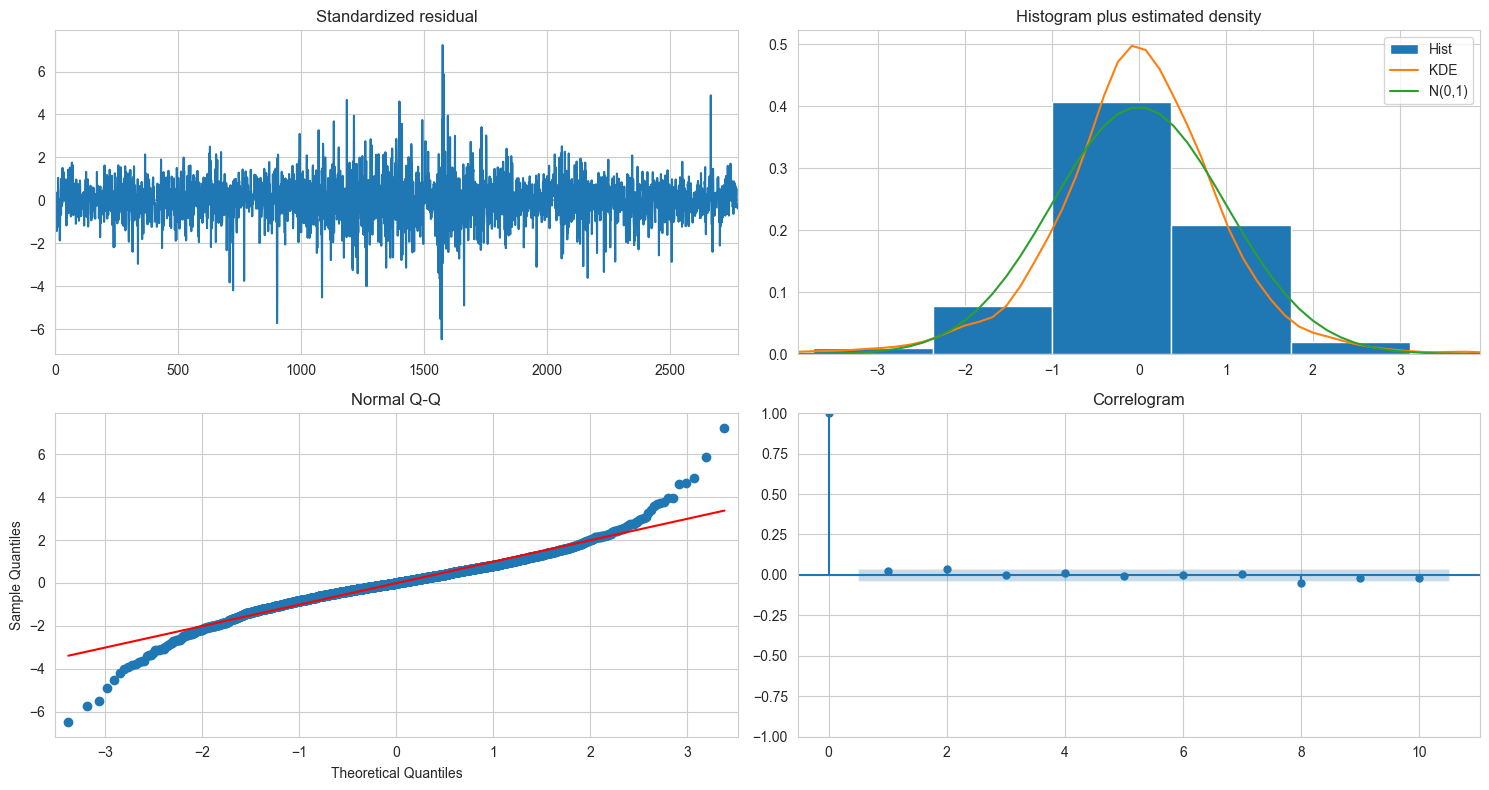

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Plot 1: Standardized Residuals Over Time
model.plot_diagnostics(figsize=(15, 8))
plt.tight_layout()
plt.show()

In [10]:
# The model summary already provides some statistical checks, but you can explicitly get it
# Note: pmdarima's model summary prints this, but if you need the stats directly:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Get the residuals from the model
residuals = model.resid()[1:]  # Start from index 1 to skip the NaN created by differencing

# Perform the Ljung-Box test
ljung_box_results = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("\n--- Ljung-Box Test Results (for first 10 lags) ---")
print(ljung_box_results)


--- Ljung-Box Test Results (for first 10 lags) ---
     lb_stat  lb_pvalue
10  15.14039   0.127027


In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Split data into train / test sets
train = data.iloc[:len(data)-10]
test = data.iloc[len(data)-10:] 

model = SARIMAX(train['ROI'],
                order=(0,0,0),
                model=None)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    ROI   No. Observations:                 2768
Model:                        SARIMAX   Log Likelihood               -4601.606
Date:                Thu, 14 May 2026   AIC                           9205.213
Time:                        22:55:59   BIC                           9211.139
Sample:                             0   HQIC                          9207.353
                               - 2768                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.6274      0.024     66.621      0.000       1.580       1.675
===================================================================================
Ljung-Box (L1) (Q):                   1.41   Jarque-Bera (JB):              2250.46
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                            -0.13
Prob(H) (two-sided):                  0.46   Kurtosis:                         7.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### INTERPRETATIONS
### Ljung-Box (Q)	0.00 (Prob(Q): 0.99)	
Tests for lack of fit (non-randomness) in the residuals. 
A high p-value (0.99) means we fail to reject the null hypothesis that the residuals are independently distributed (i.e., they are random). 
Excellent: The residuals (errors) are random and unpredictable (white noise), meaning the model has captured the underlying pattern.
### Jarque-Bera (JB)	924.69 (Prob(JB): 0.00)	
Tests for the normality of residuals. 
A p-value of 0.00 means the residuals are not normally distributed. 
Expected: Residuals are not normally distributed, indicated by the high Kurtosis (5.87). This is typical for financial data returns, which often show "fat tails" (high Kurtosis of 5.87, which is much higher than 3 for a normal distribution).
### Heteroskedasticity (H)	1.02 (Prob(H): 0.75)	
Tests for constant variance in the residuals (homoskedasticity). A high p-value (0.75) means we fail to reject the null hypothesis of homoskedasticity. 
Good: The variance of the errors is relatively constant (homoskedastic), which is ideal for forecasting.
### Significance of Coefficients (P>|z|)
The P>|z| column is the key to determining which components of the model are statistically necessary. A value less than or equal to 0.05 indicates significance. So ignoring (3, 0, 1) parameters as their p value is greater than 0.05 (0.999, 0.904, 0.999)and rerunning our tests.

In [33]:
train = data.iloc[:len(data)-(10)]
test = data.iloc[len(data)-10:] 

model = SARIMAX(train['ROI'], 
                order = (0,0,0), 
                seasonal_order =(2,1,0,12))
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                 
================================================================================
Dep. Variable:                      ROI   No. Observations:                 2768
Model:             SARIMAX(2, 1, 0, 12)   Log Likelihood               -4977.063
Date:                  Thu, 14 May 2026   AIC                           9960.127
Time:                          23:09:50   BIC                           9977.892
Sample:                               0   HQIC                          9966.544
                                 - 2768                                         
Covariance Type:                    opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.6964      0.014    -48.821      0.000      -0.724      -0.668
ar.S.L24      -0.3548      0.015    -24.456      0.000      -0.383      -0.326
sigma2         2.1628      0.038     56.907      0.000       2.088       2.237
===================================================================================
Ljung-Box (L1) (Q):                   2.13   Jarque-Bera (JB):              1022.79
Prob(Q):                              0.14   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.06
Prob(H) (two-sided):                  0.55   Kurtosis:                         5.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
from statsmodels.tsa.stattools import adfuller
# 1. Stationarity Check (ADF Test)
# The link emphasizes checking stationarity.
# We use the Augmented Dickey-Fuller (ADF) test on the ROI series.
print("ADF Test Results:")
result = adfuller(data['ROI'].dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# If p-value <= 0.05, the data is stationary, and d=0. 
# If not, we would use data['ROI'].diff().dropna() and repeat the test (d=1).

ADF Test Results:
ADF Statistic: -35.5934
p-value: 0.0000


In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX # Needed for retraining

# Define the full time series (ROI column from your full 'data' DataFrame)
full_series = data['ROI'].copy() 
N_FORECAST = 10 

# Define the split point
split_point = len(full_series) - N_FORECAST

# Lists to store the actual and predicted values
actual_values = []
predictions = []

# Walk-Forward Loop
for i in range(N_FORECAST):
    # 1. Define the current training and testing window
    current_train_data = full_series.iloc[:split_point + i]
    
    # 2. Refit the SARIMAX model (This step is computationally intensive!)
    # Use the same best parameters you found: (0, 0, 0)x(2, 1, 0)[12]
    current_model = SARIMAX(current_train_data, 
                            order = (0,0,0), # Simplified
                            seasonal_order =(2,1,[0],12))
    current_result = current_model.fit(disp=True)
    
    # 3. Generate a ONE-STEP forecast
    # Forecast index: split_point + i
    one_step_forecast = current_result.predict(start=len(current_train_data), 
                                               end=len(current_train_data))
    
    # 4. Store results and roll the window
    predictions.append(one_step_forecast.iloc[0])
    actual_values.append(full_series.iloc[split_point + i])

# Calculate final RMSE over all 10 one-day predictions
final_rmse = np.sqrt(mean_squared_error(actual_values, predictions))

print(f"Walk-Forward Forecast Summary ({N_FORECAST} Iterations)")
print(f"Final Walk-Forward RMSE (10 one-day steps): {final_rmse:.4f}")
print(f"Actual Values (last 5): {actual_values[-5:]}")
print(f"Forecasted Values (last 5): {predictions[-5:]}")

Walk-Forward Forecast Summary (10 Iterations)
Final Walk-Forward RMSE (10 one-day steps): 0.7251
Actual Values (last 5): [np.float64(-0.3806228373702425), np.float64(-0.3466204506065788), np.float64(-0.31152647975078823), np.float64(-0.24137931034483956), np.float64(-0.48459674627898897)]
Forecasted Values (last 5): [np.float64(0.908852528096822), np.float64(0.6259606416018768), np.float64(-0.1545250200918986), np.float64(0.4173687233880524), np.float64(0.11337898589830353)]


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd # Import pandas for pd.concat if not already done

# Corrected Index Calculation
# The forecast should start at the beginning of the 'test' set's data
# len(data) is the length of the full dataset
# len(test) is the number of periods to forecast (10)
# start should be the index where test begins: len(data) - len(test)
start = len(data) - len(test)

# The forecast should end at the very last index of the full dataset
end = len(data) - 1

# 1. Generate the Predictions
# The start and end indices now guarantee a length of len(test) = 10
predictions = result.predict(start=start, end=end, dynamic=False)

# 2. Reindex and Evaluate Performance
# Now that 'predictions' has 10 elements, it can be indexed by 'test.index' (which also has 10)
predictions.index = test.index 
predictions.name = 'Forecasted_ROI'

actual_roi = test['ROI']
forecasted_roi = predictions

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(actual_roi, forecasted_roi))

# 3. Print Results
print("Forecast Summary")
print(f"Number of Forecasts (should be 10): {len(predictions)}")
print(f"Actual ROI (Last 5): \n{actual_roi.tail()}")
print(f"\nForecasted ROI (Last 5): \n{forecasted_roi.tail()}")
print("\n------------------------")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Optional: Combine actual and forecast for plotting/inspection
forecast_results = pd.concat([actual_roi, forecasted_roi], axis=1)
# print(forecast_results)

Forecast Summary
Number of Forecasts (should be 10): 10
Actual ROI (Last 5): 
Date
2024-12-20   -0.380623
2024-12-23   -0.346620
2024-12-24   -0.311526
2024-12-27   -0.241379
2024-12-30   -0.484597
Name: ROI, dtype: float64

Forecasted ROI (Last 5): 
Date
2024-12-20    0.909108
2024-12-23    0.625473
2024-12-24   -0.154545
2024-12-27    0.417436
2024-12-30    0.113364
Name: Forecasted_ROI, dtype: float64

------------------------
Root Mean Squared Error (RMSE): 0.7251


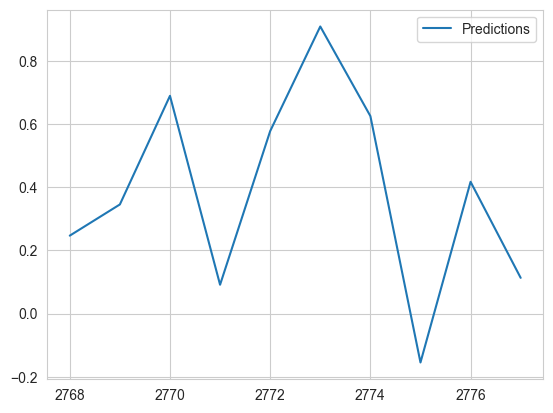

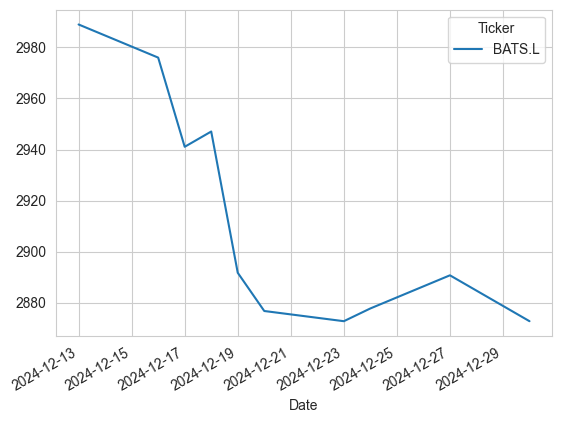

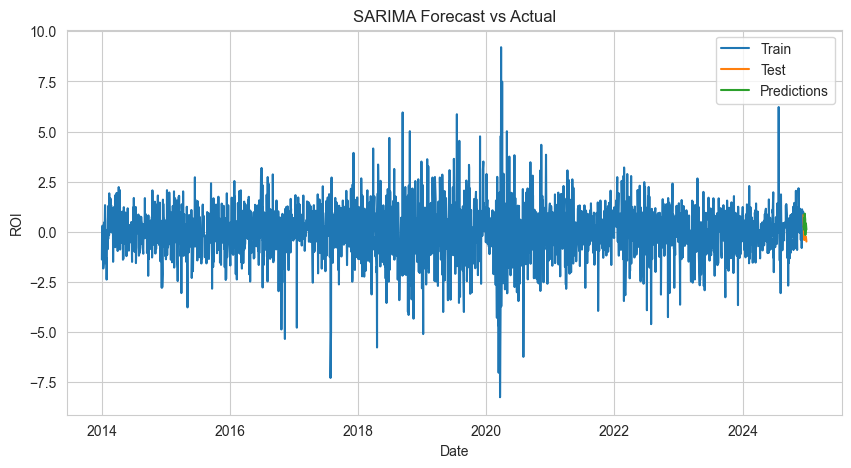

In [35]:
start = len(train)
end = len(train) + len(test) - 1

# Predictions for one-year against the test set
predictions = result.predict(start, end,
                             typ = 'levels').rename("Predictions")

# plot predictions and actual values
predictions.plot(legend = True)
test['Close'].plot(legend = True)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train.index, train['ROI'], label='Train')
plt.plot(test.index, test['ROI'], label='Test')
plt.plot(test.index, predictions, label='Predictions')
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("ROI")
plt.legend()
plt.show()


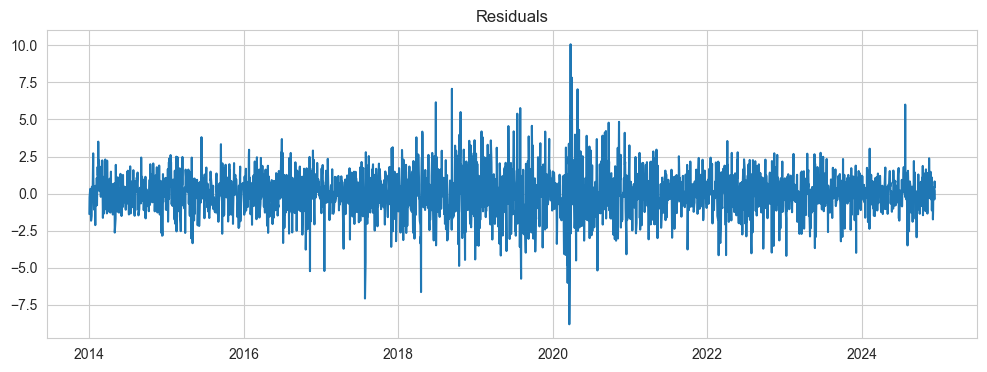

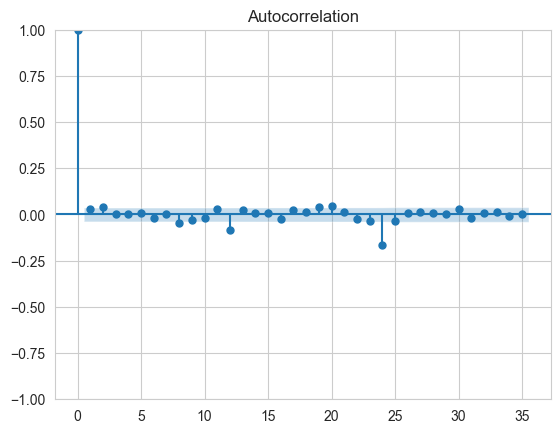

In [40]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals = result.resid
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plot_acf(residuals)
plt.show()

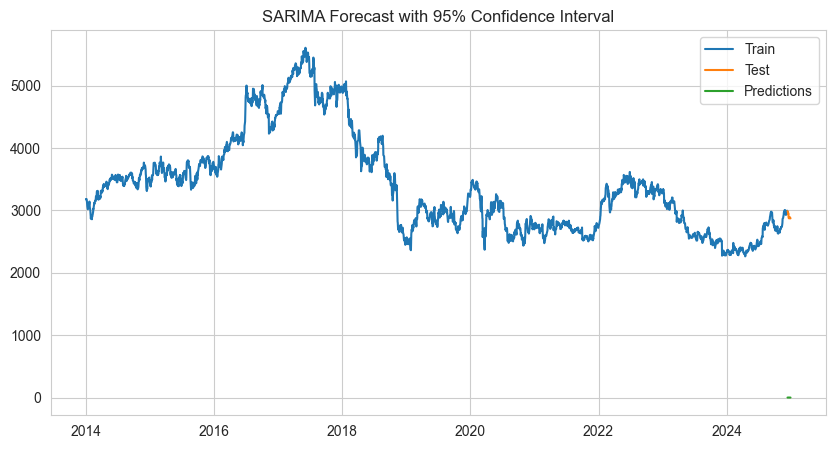

In [41]:
pred = result.get_prediction(start=start, end=end)
pred_ci = pred.conf_int()

plt.figure(figsize=(10,5))
plt.plot(train.index, train['Close'], label='Train')
plt.plot(test.index, test['Close'], label='Test')
plt.plot(test.index, pred.predicted_mean, label='Predictions')
plt.fill_between(test.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast with 95% Confidence Interval")
plt.legend()
plt.show()


In [46]:
n_periods = 12  # e.g., next 12 months
forecast = result.get_forecast(steps=n_periods)
print(forecast.predicted_mean)

2768    0.246931
2769    0.345682
2770    0.689558
2771    0.091557
2772    0.577830
2773    0.909108
2774    0.625473
2775   -0.154545
2776    0.417436
2777    0.113364
2778   -0.026569
2779    0.672455
Name: predicted_mean, dtype: float64


In [49]:
# The model has already been fitted and forecasts have been generated in previous cells
# Using the fitted 'result' object to make predictions on the test set
train_size = int(len(data) * 0.8)
train, test = data[0:train_size], data[train_size:]

# Generate predictions using the already fitted result object
n_periods = len(test)
forecast_obj = result.get_forecast(steps=n_periods)
forecast_series = forecast_obj.predicted_mean

# Display the forecasted values
print("Forecast for test period:")
print(forecast_series.head())

Forecast for test period:
2768    0.246931
2769    0.345682
2770    0.689558
2771    0.091557
2772    0.577830
Name: predicted_mean, dtype: float64
